# Actividad 2

# Información General del Dataset

**Nombre:** *Student Performance Factors Dataset*

**Fuente y liga de acceso:** *https://www.kaggle.com/datasets/mosapabdelghany/student-performance-factors-dataset*

**Fecha de consulta:** *13 de agosto de 2026 — 17 de agosto de 2026*

**Fecha de última actualización en Kaggle:** *Hace 10 meses*

**Descripción:** *Este conjunto contiene variables numéricas y categóricas relacionadas con factores académicos, personales, familiares y esoclares que pueden influir en el desempeño de los estudiantes. En esta actividad se tendrá como objetivo seleccionar las variables más importantes y entrenar los modelos para que puedan ser capaces de predecir cuáles variables son las que verdaderamente influyen.*

# Datos del Dataset

## Explicación de los registros

En este caso se usará el dataset limpio que se obtuvo de la actividad 1. Éstos son los registros originales y nuevos.

**Registros originales**
* **Hours_Studied:** *Número de horas de estudio por semana*
* **Attendance:** *Porcentaje de asistencia en el periodo*
* **Parental_Involvment:** *Nivel de apoyo académico por parte de los padres*
* **Access_to_Resources:** *Disponibilidad de recursos académicos como libros o internet*
* **Extracurricular_Activities:** *Si el estudiante está involucrado en actividades extracurriculares*
* **Sleep_Hours:** *Promedio de horas de sueño al día*
* **Previous_Scores:** *Promedio de calificaciones académicas previas*
* **Motivation_Level:** *Nivel de motivación del estudiante*
* **Internet_Access:** *Si el estudiante tiene acceso al internet*
* **Tutoring_Sessions:** *Número de sesiones de tutoría a la semana*
* **Family_Income:** *Nivel de ingresos familiares*
* **Teacher_Quality:** *Calidad general percibida de los docentes*
* **School_Type:** *Tipo de escuela (Pública o Privada)*
* **Peer_Influence:** *Influencia de los compañeros en el rendimiento académico*
* **Physical_Activity:** *Horas de actividad física a la semana*
* **Learning_Disabilities:** *Si el estudiante presenta dificultades de aprendizaje*
* **Parental_Education_Level:** *Nivel máximo de estudios de los padres*
* **Distance_from_Home:** *Distancia entre el hogar y la escuela (Cerca, Moderada, Lejos)*
* **Gender:** *Género del estudiante*
* **Exam_Score:** *Calificación final del examen*

### Variable objetivo
La variable **Exam_Score** es nuestra variable objetivo.

### Pregunta predictiva que guiará el análisis
¿Qué variables son las fundamentales para que un estudiante pueda obtener un puntaje alto en su examen? ¿Existe una combinación de variables que aumente o disminuya este puntaje?

# Paso 1 y 2

In [2]:
%pip install matplotlib seaborn pandas scikit-learn kagglehub

  Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.9.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached kagglehub-1.0.2-py3-none-any.whl.metadata (40 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached kagglesdk-0.1.37-py3-none-any.whl.metadata (13 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-win_amd64.whl.metadata (2.4 kB)
  Using cached re


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import kagglehub
from kagglehub import KaggleDatasetAdapter

c:\Users\Leo_1\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Limpieza que se realizó en la Actividad 1

In [4]:
def clean_data():
    # Load the dataset from Kaggle
    file_path = "StudentPerformanceFactors.csv"
    
    df = kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        "mosapabdelghany/student-performance-factors-dataset",
        file_path,
    )
    
    # Columns of type string with missing values
    df_objects = df.select_dtypes(include=['object'])
    missing_columns = df_objects.columns[df_objects.isnull().any()].tolist()
    
    # Columns of type int64 with missing values
    #df_int64 = df.select_dtypes(include=['int64'])
    #missing_columns += df_int64.columns[df_int64.isnull().any()].tolist()
    
    # Print the number of missing values for each column with missing values
    for column in missing_columns:
        print(f"Valores faltantes en '{column}': {df[column].isnull().sum()}")
    
    # Fill missing values with the mode of the respective columns
    for column in missing_columns:
        df[column] = df[column].fillna(df[column].mode()[0])
        
    # Convert hierarchical categorical variables to numerical using one-hot encoding
    map_level = {
      'Low': 0,
      'Medium': 1,
      'High': 2
    }
    
    hc_columns = ['Parental_Involvement', 'Motivation_Level']
    
    for column in hc_columns:
        df[f'{column}_encoded'] = df[column].map(map_level)
        
    # Convert categorical variables to numerical using one-hot encoding
    df = pd.get_dummies(df, columns=['School_Type', 'Internet_Access'], drop_first=True, dtype=int)
    
    # Clean atypical values in Exam_Score column
    over_100 = (df['Exam_Score'] > 100).sum()
    print(f"\nRegistros con calificación mayor a 100 en 'Exam_Score': {over_100}")
    
    under_100 = (df['Exam_Score'] < 0).sum()
    print(f"Registros con calificación menor a 0 en 'Exam_Score': {under_100}")
    
    df.loc[df['Exam_Score'] > 100, 'Exam_Score'] = 100
    df.loc[df['Exam_Score'] < 0, 'Exam_Score'] = 0
    
    print("\nValor mínimo y máximo de 'Exam_Score' después de la limpieza:")
    print(f"Valor mínimo: {df['Exam_Score'].min()}")
    print(f"Valor máximo: {df['Exam_Score'].max()}")
    
    # Standard scaling of 'Hours_Studied' and 'Attendance'
    cols_to_scale = ['Hours_Studied', 'Attendance']
    scaler = StandardScaler()
    
    for column in cols_to_scale:
        df[f'{column}_scaled'] = scaler.fit_transform(df[[column]])
        
    return df

df = clean_data()

print("Descripción estadística del DataFrame:")
print(f"\nNúmero total de registros: {len(df)}")
print(f"\nNúmero de columnas: {len(df.columns)}")

print("\nValidación de cero valores nulos en el DataFrame:")
print(f"Valores nulos en el DataFrame: {df.isnull().sum().sum()}")

print("\nTipos de datos de las columnas después de la limpieza:")
print(df.dtypes)

print("\nNúmero de registros duplicados en el DataFrame después de la limpieza:")
print(df.duplicated().sum())

df.describe(include="all")

Valores faltantes en 'Teacher_Quality': 78
Valores faltantes en 'Parental_Education_Level': 90
Valores faltantes en 'Distance_from_Home': 67

Registros con calificación mayor a 100 en 'Exam_Score': 1
Registros con calificación menor a 0 en 'Exam_Score': 0

Valor mínimo y máximo de 'Exam_Score' después de la limpieza:
Valor mínimo: 55
Valor máximo: 100
Descripción estadística del DataFrame:

Número total de registros: 6607

Número de columnas: 24

Validación de cero valores nulos en el DataFrame:
Valores nulos en el DataFrame: 0

Tipos de datos de las columnas después de la limpieza:
Hours_Studied                     int64
Attendance                        int64
Parental_Involvement                str
Access_to_Resources                 str
Extracurricular_Activities          str
Sleep_Hours                       int64
Previous_Scores                   int64
Motivation_Level                    str
Tutoring_Sessions                 int64
Family_Income                       str
Teacher_Qu

C:\Users\Leo_1\AppData\Local\Temp\ipykernel_37228\3144117402.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_objects = df.select_dtypes(include=['object'])


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,...,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Parental_Involvement_encoded,Motivation_Level_encoded,School_Type_Public,Internet_Access_Yes,Hours_Studied_scaled,Attendance_scaled
count,6607.000000,6607.000000,6607,6607,6607,6607.00000,6607.000000,6607,6607.000000,6607,...,6607,6607,6607,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6.607000e+03,6.607000e+03
unique,NaN,NaN,3,3,2,NaN,NaN,3,NaN,3,...,3,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Medium,Medium,Yes,NaN,NaN,Medium,NaN,Low,...,High School,Near,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,3362,3319,3938,NaN,NaN,3351,NaN,2672,...,3313,3951,3814,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,19.975329,79.977448,NaN,NaN,NaN,7.02906,75.070531,NaN,1.493719,NaN,...,NaN,NaN,NaN,67.235508,1.086423,0.906463,0.695929,0.924474,-1.161474e-16,-3.089199e-16
std,5.990594,11.547475,NaN,NaN,NaN,1.46812,14.399784,NaN,1.230570,NaN,...,NaN,NaN,NaN,3.889161,0.695521,0.695798,0.460048,0.264258,1.000076e+00,1.000076e+00
min,1.000000,60.000000,NaN,NaN,NaN,4.00000,50.000000,NaN,0.000000,NaN,...,NaN,NaN,NaN,55.000000,0.000000,0.000000,0.000000,0.000000,-3.167760e+00,-1.730158e+00
25%,16.000000,70.000000,NaN,NaN,NaN,6.00000,63.000000,NaN,1.000000,NaN,...,NaN,NaN,NaN,65.000000,1.000000,0.000000,0.000000,1.000000,-6.636453e-01,-8.641026e-01
50%,20.000000,80.000000,NaN,NaN,NaN,7.00000,75.000000,NaN,1.000000,NaN,...,NaN,NaN,NaN,67.000000,1.000000,1.000000,1.000000,1.000000,4.118568e-03,1.953115e-03
75%,24.000000,90.000000,NaN,NaN,NaN,8.00000,88.000000,NaN,2.000000,NaN,...,NaN,NaN,NaN,69.000000,2.000000,1.000000,1.000000,1.000000,6.718825e-01,8.680088e-01


# Conclusión y Justificación de Cambios

**Registros nuevos**
* **Parental_Involvement_Encoded:** *Nivel de apoyo académico por parte de los padres medido en valores númericos (del 0 al 2)*
* **Motivation_Level_Encoded:** *Niveo de motivación del estudiante medido en valores númericos (del 0 al 2)*
* **School_Type_Private:** *Si el estudiante atiende escuela privada (0 siendo Falso y 1 siendo Verdadero)*
* **School_Type_Public:** *Si el estudiante atiende escuela pública (0 siendo Falso y 1 siendo Verdadero)*
* **Internet_Access_No:** *Si el estudiante no posee acceso a internet (0 siendo Falso y 1 siendo Verdadero)*
* **Internet_Access_Yes:** *Si el estudiante sí posee acceso a internet (0 siendo Falso y 1 siendo Verdadero)*
* **Hours_Studied_Scaled:** *Número de horas de estudio por semana estandarizadas. Centrado en 0 con una desviación estándar de 1.*
* **Attendance_Scaled:** *Porcentaje de asistencia en el periodo estandarizado. Centrado en 0 con una desviación estándar de 1.*

(JAIR: AQUÍ ME FALTA PONER LA JUSTIFICACIÓN)

# Paso 3

Explorando la variable 'Exam_Score'


Estadística descriptiva de la columna 'Exam_Score':


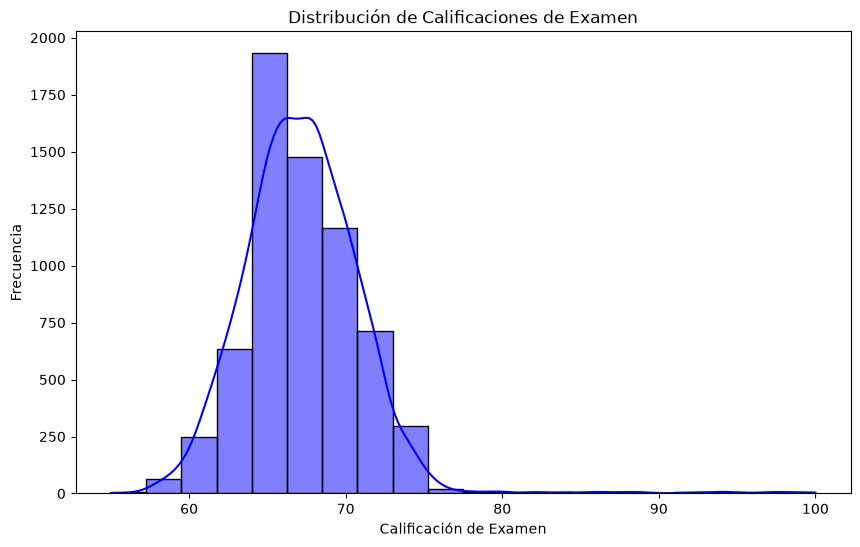

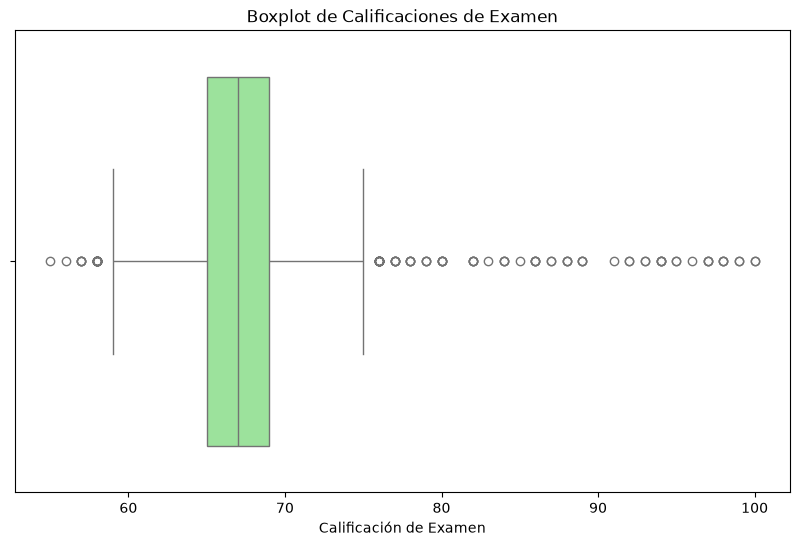

In [5]:
print("\nEstadística descriptiva de la columna 'Exam_Score':")
df['Exam_Score'].describe()

# Histogram of 'Exam_Score'
plt.figure(figsize=(10, 6))
sns.histplot(df['Exam_Score'], bins=20, kde=True, color='blue')
plt.title('Distribución de Calificaciones de Examen')
plt.xlabel('Calificación de Examen')
plt.ylabel('Frecuencia')
plt.show()

# Boxplot of 'Exam_Score'
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Exam_Score'], color='lightgreen')
plt.title('Boxplot de Calificaciones de Examen')
plt.xlabel('Calificación de Examen')
plt.show()

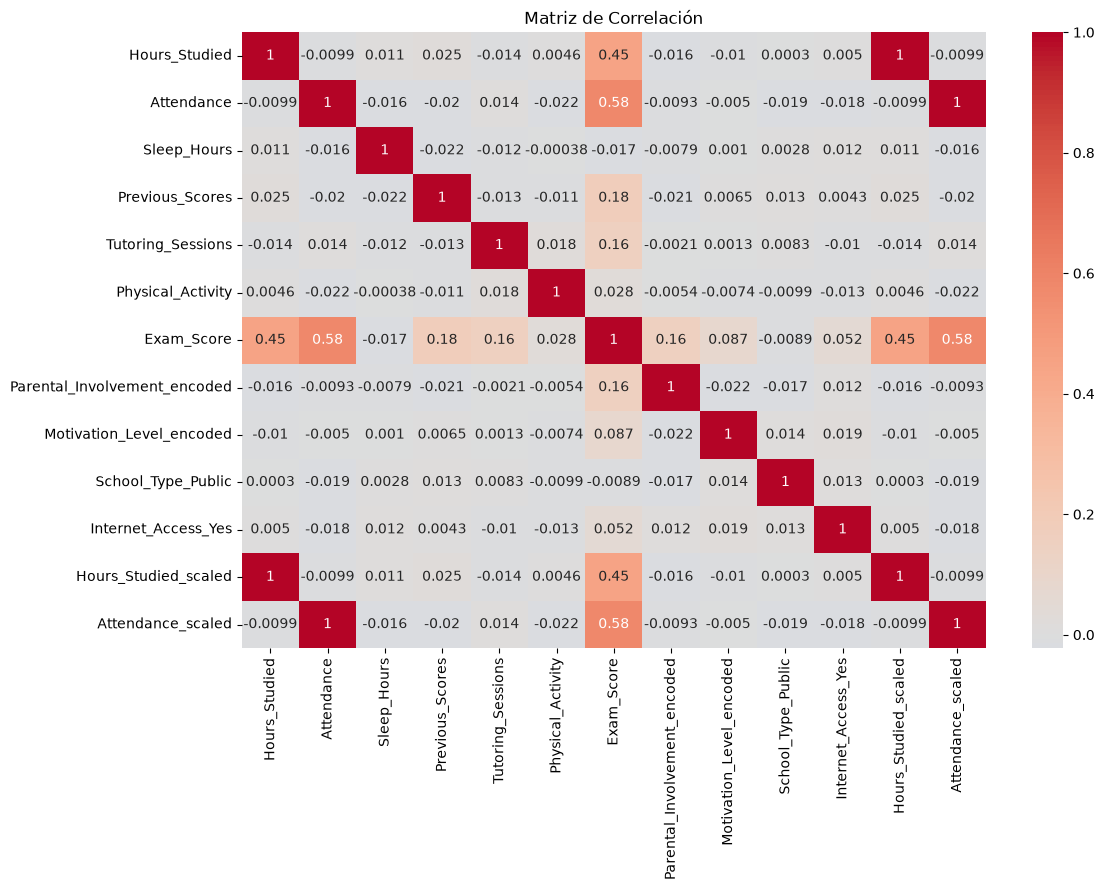

In [6]:
# Correlation heatmap of the numerical columns
plt.figure(figsize=(12, 8))
numerical_columns = df.select_dtypes(include=['number']).columns
correlation_matrix = df[numerical_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()

# EN RESUMEN

Sólo las variables Attendance y Hours_Studied merecen la pena ser exploradas como posibles causas de un mejor resultado en el examen.

# Paso 4

In [7]:
from sklearn.model_selection import train_test_split

# Definimos la variable objetivo y las variables dependientes.
x = df[['Attendance', 'Hours_Studied']] 
y = df['Exam_Score']

#Dividimos el dataset en conjuntos de entrenamiento y prueba (80% / 20%) con una semilla fija de 42 para asegurar un resultado reproducible.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [8]:
print(f"Tamaño de entrenamiento (x_train): {x_train.shape}")
print(f"Tamaño de prueba (x_test): {x_test.shape}")

Tamaño de entrenamiento (x_train): (5285, 2)
Tamaño de prueba (x_test): (1322, 2)


# Paso 5

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Definimos las columnas numericas de las variables seleccionadas.
numeric_features = ['Attendance', 'Hours_Studied']

# Pipeline numerico.
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ])


# Paso 6

In [10]:
from sklearn.dummy import DummyRegressor

# Construimos y entrenamos el modelo base usando la media
dummy_regr = DummyRegressor(strategy="mean")
dummy_regr.fit(x_train, y_train)

# Generamos predicciones base
y_pred_dummy = dummy_regr.predict(x_test)

In [11]:
print(f"Valor promedio obtenido del modelo: {y_pred_dummy[0]:.2f}")
print(f"Primeras 5 predicciones: {y_pred_dummy[:5]}")

Valor promedio obtenido del modelo: 67.21
Primeras 5 predicciones: [67.21494797 67.21494797 67.21494797 67.21494797 67.21494797]


# Paso 7

In [12]:
from sklearn.linear_model import LinearRegression

# Modelo de Regresión Lineal
pipeline_lineal = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Entrenamiento del pipeline
pipeline_lineal.fit(x_train, y_train)

# Predicciones sobre el conjunto de prueba
y_pred_lineal = pipeline_lineal.predict(x_test)

In [13]:
print("Primeras 5 predicciones (Regresión Lineal):")
print(y_pred_lineal[:5])

Primeras 5 predicciones (Regresión Lineal):
[65.46386758 66.04165818 69.7209176  67.12085991 64.165501  ]


In [14]:
from sklearn.tree import DecisionTreeRegressor

# Modelo de Árbol de Regresión
pipeline_arbol = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42, max_depth=5)) # max_depth=5 para evitar sobreajuste
])

# Entrenamiento del pipeline
pipeline_arbol.fit(x_train, y_train)

# Predicciones sobre el conjunto de prueba
y_pred_arbol = pipeline_arbol.predict(x_test)



In [15]:
print("Primeras 5 predicciones (Árbol de Regresión):")
print(y_pred_arbol[:5])

Primeras 5 predicciones (Árbol de Regresión):
[65.22177419 66.28753181 69.93192488 65.78421053 64.8021978 ]


# Paso 8

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Función para calcular las tres métricas
def calcular_metricas(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return round(mae, 4), round(rmse, 4), round(r2, 4)

# Calculamos las métricas para los 3 modelos
mae_base, rmse_base, r2_base = calcular_metricas(y_test, y_pred_dummy)
mae_lin, rmse_lin, r2_lin = calcular_metricas(y_test, y_pred_lineal)
mae_arbol, rmse_arbol, r2_arbol = calcular_metricas(y_test, y_pred_arbol)

# Construimos la tabla de resultados
tabla_resultados = {
    'Modelo': ['Línea base', 'Regresión lineal', 'Modelo alternativo (Árbol)'],
    'MAE': [mae_base, mae_lin, mae_arbol],
    'RMSE': [rmse_base, rmse_lin, rmse_arbol],
    'R²': [r2_base, r2_lin, r2_arbol]
}

df_resultados = pd.DataFrame(tabla_resultados)

In [17]:
# Mostramos la tabla
print("Tabla de Resultados:")
display(df_resultados)

Tabla de Resultados:


,Modelo,MAE,RMSE,R²
0,Línea base,2.8235,3.7611,-0.0007
1,Regresión lineal,1.4690,2.4102,0.5890
2,Modelo alternativo (Árbol),1.5918,2.5128,0.5533


# Paso 9

Interpretación de Métricas de Evaluación 

Al evaluar el rendimiento de los modelos frente a la línea base, la Regresión Lineal demostró ser la mejor opción para este conjunto de datos.

Su Error Absoluto Medio (MAE) fue de 1.4690 puntos. Esto representa que, en promedio, las predicciones del modelo se desvían por apenas un punto y medio respecto a la calificación real del estudiante. Considerando una escala de evaluación típica (por ejemplo, de 0 a 100), un margen de error tan pequeño indica que el modelo tiene una gran utilidad práctica. Nos permite estimar el desempeño académico de un alumno de manera bastante confiable, ayudando a identificar a tiempo si un estudiante requiere más apoyo.

Por otro lado, el RMSE obtenido por la regresión lineal fue de 2.4102. Como esta métrica penaliza con mayor intensidad los errores grandes al elevarlos al cuadrado antes de promediarlos, el hecho de que sea superior al MAE nos revela información importante: existen casos con errores de estimación más amplios. En el contexto escolar, esto es completamente natural, ya que siempre habrá estudiantes "atípicos" cuyos resultados rompen la tendencia (por ejemplo, alguien que estudia muy pocas horas pero obtiene una calificación excelente por conocimientos previos, o viceversa).

Finalmente, el coeficiente $R^2$ de 0.5890 aporta claridad sobre el nivel de ajuste del modelo. Esto significa que casi el 59% de la variabilidad en las calificaciones de los exámenes (Exam_Score) puede explicarse utilizando únicamente dos variables: la Asistencia y las Horas de Estudio. El ~41% restante obedece a factores que no introdujimos en este modelo, demostrando que aunque el tiempo invertido y la asistencia son pilares fundamentales, el éxito académico sigue siendo un fenómeno multifactorial.

# Paso 10

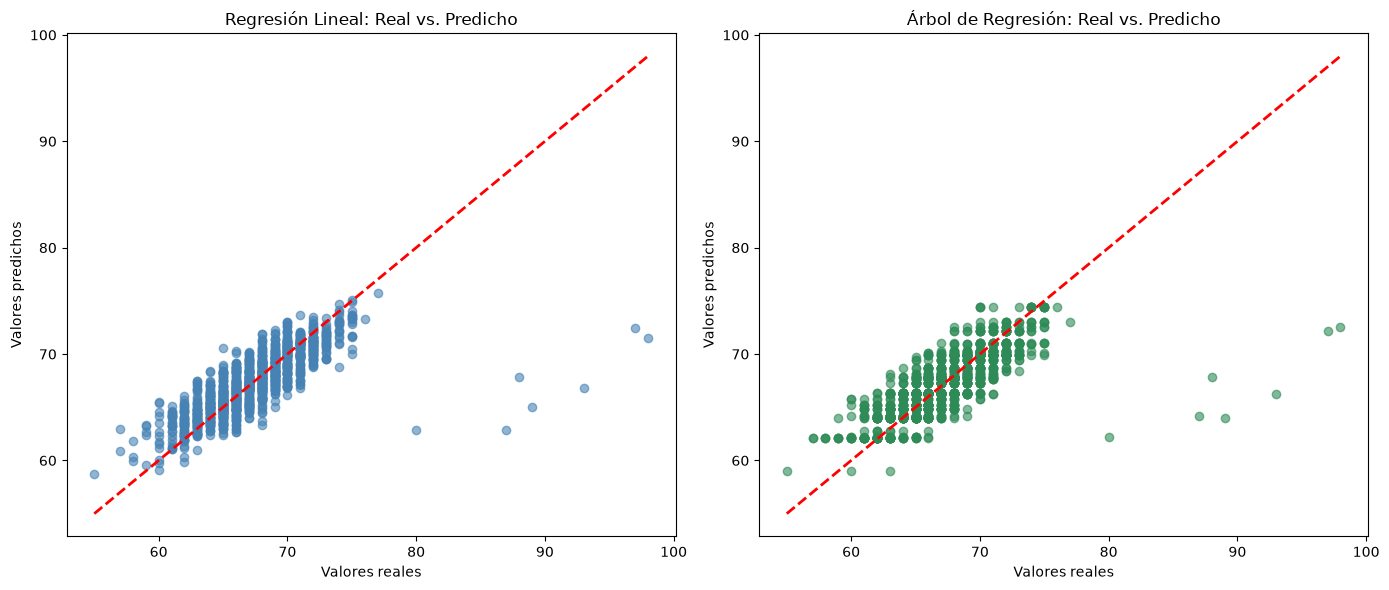

Modelo con mejor desempeño: Regresión lineal


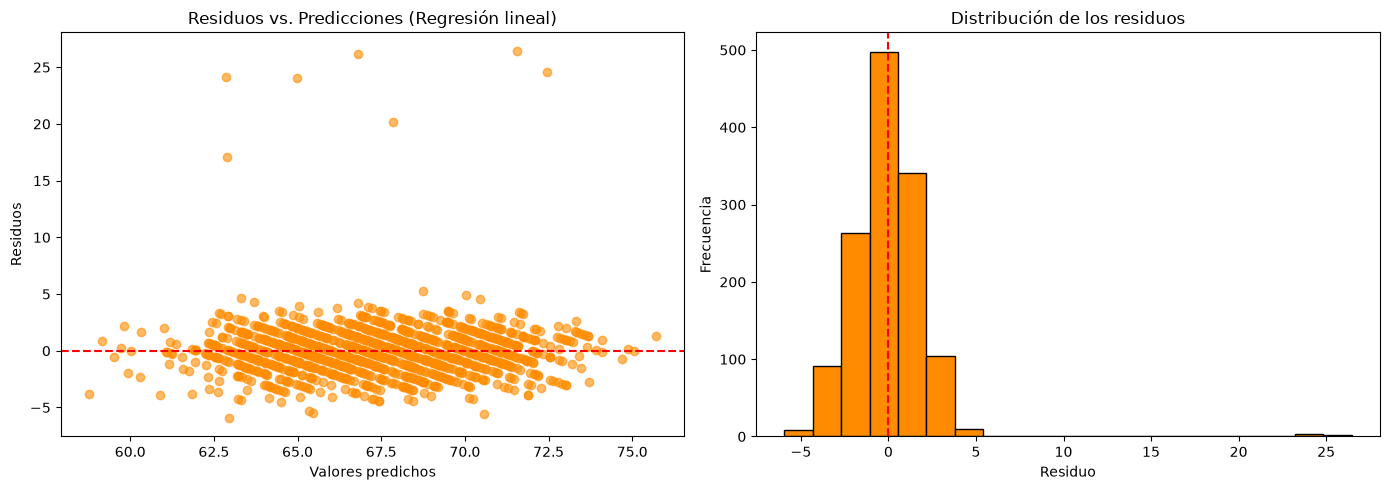

Media de residuos: -0.0121
Desviación estándar de residuos: 2.4111


In [ ]:
import matplotlib.pyplot as plt

# Valores reales vs valores predichos para los dos modelos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, y_pred_lineal, alpha=0.6, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Valores reales')
axes[0].set_ylabel('Valores predichos')
axes[0].set_title('Regresión Lineal: Real vs. Predicho')

axes[1].scatter(y_test, y_pred_arbol, alpha=0.6, color='seagreen')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Valores reales')
axes[1].set_ylabel('Valores predichos')
axes[1].set_title('Árbol de Regresión: Real vs. Predicho')

plt.tight_layout()
plt.show()

# Identificamos el modelo con mejor desempeño según R²
mejor_modelo = df_resultados.loc[df_resultados['R²'].idxmax(), 'Modelo']
print(f"Modelo con mejor desempeño: {mejor_modelo}")

# Elegimos las predicciones del mejor modelo
if mejor_modelo == 'Regresión lineal':
    y_pred_mejor = y_pred_lineal
else:
    y_pred_mejor = y_pred_arbol

residuos = y_test - y_pred_mejor

# Análisis de residuos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuos vs valores predichos (para ver patrones/heterocedasticidad)
axes[0].scatter(y_pred_mejor, residuos, alpha=0.6, color='darkorange')
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Valores predichos')
axes[0].set_ylabel('Residuos')
axes[0].set_title(f'Residuos vs. Predicciones ({mejor_modelo})')

# Distribución de los residuos
axes[1].hist(residuos, bins=20, color='darkorange', edgecolor='black')
axes[1].axvline(x=0, color='r', linestyle='--')
axes[1].set_xlabel('Residuo')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de los residuos')

plt.tight_layout()
plt.show()

print(f"Media de residuos: {residuos.mean():.4f}")
print(f"Desviación estándar de residuos: {residuos.std():.4f}")

Analisis de residuos

Los residuos se distribuyen de manera aproximadamente aleatoria alrededor de cero para 
la mayoría de las observaciones, sin un patrón sistemático evidente (no hay forma de 
embudo ni curvatura), lo que sugiere que el modelo captura razonablemente bien la 
relación lineal en el rango central de los datos (puntajes entre 60 y 75).

Sin embargo, se observa un grupo claro de valores atípicos: estudiantes con puntajes 
reales altos (80-98) para los cuales el modelo predice consistentemente valores mucho 
más bajos (60-73), generando residuos grandes (17-26). Esto se refleja en el histograma 
como una cola larga hacia la derecha, rompiendo la simetría de la distribución.

Esto indica que el modelo tiene dificultades específicas para predecir a los estudiantes 
de alto rendimiento, probablemente porque estos casos son poco frecuentes en los datos 
de entrenamiento y el modelo lineal tiende a "regresar hacia la media" en lugar de 
capturar esos extremos.